# Effects of Perceived Transport Integration - Reproduction Code

This code builds the dataset and exports them to .dta files. Then Analysis.do will read those .dta files in Stata and analyse the data.

Note: I use Chatgpt and Claude to assist me in writing code.

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import glob
import importlib
import matplotlib.pyplot as plt

import functions
importlib.reload(functions)

from functions import (
    DEFAULT_POST_YEARS,
    DEFAULT_PRE_YEARS,
    apply_prepost_filter,
    assign_nearest_station,
    create_control_group,
    estimation_baseline_stats,
    estimation_overall_stats,
    estimation_support_counts,
    finalize_map,
    format_blank_row,
    format_int_or_blank,
    format_row,
    get_price_columns,
    make_gdf,
    save_dta,
)


## Cleaning Stations Data

### Treated stations

In [2]:
# Load list of newly added (treated) stations
added_stations = pd.read_csv('input/added_stations.csv')['station'].dropna().tolist()

In [3]:
# Load National Rail station attributes (coordinates, operator, local authority)
stations_df = pd.read_excel('input/station-attributes-for-all-mainline-stations.xlsx', sheet_name='6329_station_attributes')

In [4]:
# Fix header: raw Excel has metadata in first two rows; row 3 holds column names
stations_df.columns = stations_df.iloc[2]
stations_df = stations_df.iloc[3:]
stations_df = stations_df.reset_index(drop=True)

In [5]:
# Keep stations in the study region and retain treated stations explicitly.
stations_df = stations_df[
    (stations_df['Region'].str.contains('London', na=False)) | 
    (stations_df['Region'].str.contains('South East', na=False, case=False)) |
    (stations_df['Region'].str.contains('East of England', na=False, case=False)) |
    (stations_df['Station name'].isin(added_stations))
]

In [6]:
# Retain only relevant columns
stations_df = stations_df[["Station name", "National Location Code", "Ordnance Survey grid: \nEasting", "Ordnance Survey grid: \nNorthing", "Local authority: district or unitary", 'Station facility owner']]

In [7]:
# Rename to shorter column names
stations_df = stations_df.rename(columns={
    'Ordnance Survey grid: \nEasting': 'Eastings',
    'Ordnance Survey grid: \nNorthing': 'Northings',
    'Local authority: district or unitary': 'Local authority'
})

In [8]:
# Filter to treated (newly added) stations only
stations_treated_df = stations_df[stations_df['Station name'].isin(added_stations)]

In [9]:
# Debug: check which requested treated stations are not found in the station attributes data
available_station_names = set(stations_df['Station name'].dropna())
missing_treated_stations = sorted(set(added_stations) - available_station_names)

print('Treated-station match check')
print(f'Requested treated stations: {len(added_stations)}')
print(f'Matched treated stations: {len(stations_treated_df)}')
print(f'Missing treated stations: {len(missing_treated_stations)}')

if missing_treated_stations:
    for station in missing_treated_stations:
        print(f'  - {station}')
else:
    print('All requested treated stations were found.')


Treated-station match check
Requested treated stations: 45
Matched treated stations: 45
Missing treated stations: 0
All requested treated stations were found.


### Control stations

Criteria: inside fare zones, not tube/overground/tram/elizabeth/thameslink (any interchange marked on map)

In [10]:
# Load control station lists by operator; exclude Southern (subsumed into Thameslink)
control_stations_df = pd.read_csv('input/control_NR_stations.csv')
operators = [op for op in control_stations_df['operator'].unique().tolist() if op != 'Southern']

for operator in operators:
    globals()[f'{operator}_stations'] = control_stations_df[control_stations_df['operator'] == operator]['station'].tolist()

In [11]:
# Create station dataframes for all operators
for operator in operators:
    station_list = globals()[f'{operator}_stations']
    globals()[f'stations_{operator}_df'] = stations_df[stations_df['Station name'].isin(station_list)]

## Cleaning Houses Data

In [12]:
# Read combined price paid data (all years after 2015)
pp_all = pd.read_csv('input/price-paid-data/pp-after-2015.csv', header=None, usecols=[1, 2, 3, 7, 8, 12, 13])
pp_all.columns = ['price', 'date', 'postcode', 'PAON', 'SAON', 'local authority', 'county']

# Extract year and month from date column
pp_all['date'] = pd.to_datetime(pp_all['date'])
pp_all['year'] = pp_all['date'].dt.year
pp_all['month'] = pp_all['date'].dt.month

# Keep 2016-2025
pp_all = pp_all[pp_all['year'].between(2016, 2025)]

# Create year_month label for pivoting (e.g. "2017_01")
pp_all['year_month'] = pp_all['year'].astype(str) + '_' + pp_all['month'].astype(str).str.zfill(2)
pp_all = pp_all.drop(columns=['date', 'year', 'month'])

In [13]:
# Choose counties to include
target_counties = ['GREATER LONDON']

# Filter by county
pp_filtered = pp_all[pp_all['county'].isin(target_counties)].copy()

pp_filtered['local authority'] = pp_filtered['local authority'].replace({'SHEPWAY': 'FOLKESTONE AND HYTHE'})
pp_filtered['local authority'] = pp_filtered['local authority'].replace({'CITY OF WESTMINSTER': 'WESTMINSTER'})

# Pivot to wide format: one column per year-month (e.g. price_2017_01)
houses_df = pp_filtered.pivot_table(
    index=['postcode', 'PAON', 'SAON', 'local authority', 'county'],
    columns='year_month',
    values='price',
    aggfunc='first'
).reset_index()

# Flatten column names: MultiIndex -> price_YYYY_MM
houses_df.columns = [f'price_{col}' if col not in ['postcode', 'PAON', 'SAON', 'local authority', 'county'] else col for col in houses_df.columns]
houses_df.columns.name = None

In [14]:
# Pre-treatment: 2016_01 to 2020_12 | Post-treatment: 2021_01 to 2025_12
# No postcode-level pre+post filter — all houses kept for larger sample
pre_years = list(DEFAULT_PRE_YEARS)
post_years = list(DEFAULT_POST_YEARS)

pre_treatment = get_price_columns(houses_df.columns, pre_years)
post_treatment = get_price_columns(houses_df.columns, post_years)


In [15]:
# Remove duplicates - keep first entry
houses_df = houses_df.drop_duplicates(subset=['postcode', 'PAON', 'SAON', 'local authority', 'county'], keep='first')

# Reorder columns
price_columns = [col for col in houses_df.columns if col.startswith('price_')]
column_order = ['postcode', 'PAON', 'SAON', 'local authority', 'county'] + sorted(price_columns)
houses_df = houses_df[column_order]

In [16]:
# Get all CSV files in folder
csv_files = glob.glob('input/postcode-to-coordinates/Data/CSV/*.csv')

# Read and combine all CSVs
combined_df = pd.concat([pd.read_csv(f, header=None) for f in csv_files], ignore_index=True)

In [17]:
# Merge including Local authority (column 1)
houses_df = houses_df.merge(
    combined_df.iloc[:, [0, 2, 3]],  # Include column 1 (Local authority)
    left_on='postcode',
    right_on=combined_df.columns[0],
    how='left'
)

# Rename columns
houses_df.rename(columns={
    combined_df.columns[2]: 'Eastings',
    combined_df.columns[3]: 'Northings'
}, inplace=True)

# Drop duplicate postcode column
houses_df.drop(columns=[combined_df.columns[0]], inplace=True)
houses_df = houses_df.reset_index(drop=True)
houses_df = houses_df[houses_df['postcode'].notna()]

In [18]:
# Record local authorities present in the merged houses dataset
local_authorities_houses = houses_df['local authority'].dropna().unique().tolist()

## Adding controls

### Additional dwellings

In [19]:
# Parse additional dwellings data (LT_122); reshape to one row per local authority with year columns
df = pd.read_excel('input/additional_dwellings.ods', sheet_name='LT_122', engine='odf')
df = df.iloc[2:]
df = df.reset_index(drop=True)
df.columns = df.iloc[1]
df = df.iloc[2:]
df = df.reset_index(drop=True)

new_columns = []
for col in df.columns:
    col_str = str(col)
    if '-' in col_str and col_str[:4].isdigit():
        year_part = col_str.split('-')[1].split()[0]
        new_columns.append(year_part)
    else:
        new_columns.append(col)
df.columns = new_columns

cols_to_keep = []
for col in df.columns:
    if str(col).isdigit() and len(str(col)) == 2:
        year = int(col)
        if year >= 17:
            cols_to_keep.append(col)
    else:
        cols_to_keep.append(col)
df = df[cols_to_keep]

df = df.iloc[:, 3:]
df = df.rename(columns={'Authority data': 'local authority'})
df['local authority'] = df['local authority'].str.replace(' UA', '', regex=False)
df['local authority'] = df['local authority'].str.upper()

final_columns = {}
for col in df.columns:
    if str(col).isdigit() and len(str(col)) == 2:
        year = int(col)
        full_year = 1999 + year
        final_columns[col] = f'additional_dwellings_{full_year}'
    else:
        final_columns[col] = col

df = df.rename(columns=final_columns)

# Convert all additional_dwellings columns to numeric
for col in df.columns:
    if col.startswith('additional_dwellings_'):
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Extrapolate 2025 from 2023-2024 linear trend
df['additional_dwellings_2025'] = 2 * df['additional_dwellings_2024'] - df['additional_dwellings_2023']

additional_dwellings_df = df

In [20]:
# Merge additional dwellings controls into houses dataset
houses_df = houses_df.merge(additional_dwellings_df, on='local authority', how='left')

### EPC data

In [21]:
# Find all certificates.csv files in EPC folder and subfolders
csv_files = glob.glob('input/EPC/**/certificates.csv', recursive=True)

epc_cols = ['POSTCODE', 'ADDRESS1', 'INSPECTION_DATE', 'PROPERTY_TYPE', 'BUILT_FORM',
            'TOTAL_FLOOR_AREA', 'NUMBER_HABITABLE_ROOMS', 'CONSTRUCTION_AGE_BAND',
            'TENURE', 'EXTENSION_COUNT']
prop_cols = ['PROPERTY_TYPE', 'BUILT_FORM', 'TOTAL_FLOOR_AREA',
             'NUMBER_HABITABLE_ROOMS', 'CONSTRUCTION_AGE_BAND', 'TENURE', 'EXTENSION_COUNT']

# Read and combine all CSVs
chunks = []
for file in csv_files:
    df = pd.read_csv(file, usecols=epc_cols)
    chunks.append(df)

epc_df = pd.concat(chunks, ignore_index=True)

# Normalize for matching
epc_df['addr1_clean'] = epc_df['ADDRESS1'].fillna('').str.upper().str.strip()
epc_df['pc_clean'] = epc_df['POSTCODE'].fillna('').str.strip().str.upper()

# Keep most recent EPC per unique address within postcode
epc_df['INSPECTION_DATE'] = pd.to_datetime(epc_df['INSPECTION_DATE'], errors='coerce')
epc_df = epc_df.sort_values('INSPECTION_DATE', ascending=False)
epc_df = epc_df.drop_duplicates(subset=['pc_clean', 'addr1_clean'], keep='first')

# Prepare house matching keys
houses_df['saon_clean'] = houses_df['SAON'].fillna('').str.upper().str.strip()
houses_df['pc_clean'] = houses_df['postcode'].str.strip().str.upper()

# Step 1: Match on postcode + SAON = ADDRESS1 (catches individual flats)
epc_match = epc_df[['pc_clean', 'addr1_clean'] + prop_cols].copy()
houses_df = houses_df.merge(
    epc_match,
    left_on=['pc_clean', 'saon_clean'],
    right_on=['pc_clean', 'addr1_clean'],
    how='left',
    suffixes=('', '_epc')
)
matched_mask = houses_df['PROPERTY_TYPE'].notna()
print(f"Matched at house level (postcode+SAON): {matched_mask.sum()}")

# Step 2: For unmatched, fall back to postcode-level (most recent EPC at that postcode)
epc_postcode = epc_df.drop_duplicates(subset='pc_clean', keep='first')[['pc_clean'] + prop_cols]
unmatched = houses_df[~matched_mask].drop(columns=prop_cols + ['addr1_clean'], errors='ignore')
unmatched = unmatched.merge(epc_postcode, on='pc_clean', how='left')

houses_df.loc[~matched_mask, prop_cols] = unmatched[prop_cols].values
print(f"Matched at postcode level (fallback): {(~matched_mask & houses_df['PROPERTY_TYPE'].notna()).sum()}")

# Drop helper columns and keep only houses with EPC data
houses_df = houses_df.drop(columns=['addr1_clean', 'saon_clean', 'pc_clean'], errors='ignore')
houses_df = houses_df[houses_df['PROPERTY_TYPE'].notna()]

print(f"Total houses with EPC data: {len(houses_df)}")


Matched at house level (postcode+SAON): 166711
Matched at postcode level (fallback): 197328
Total houses with EPC data: 364039


In [22]:
# Merge Output Area (OA) codes
oa_lookup = pd.read_csv('input/PCD_OA21_LSOA21_MSOA21_LAD_AUG23_UK_LU.csv', usecols=['pcds', 'oa21cd'], encoding='latin-1')
oa_lookup = oa_lookup.rename(columns={'pcds': 'postcode'})
oa_lookup = oa_lookup.drop_duplicates(subset='postcode')
houses_df = houses_df.merge(oa_lookup, on='postcode', how='left')
n_before_oa = len(houses_df)
houses_df = houses_df[houses_df['oa21cd'].notna()]
print(f"Houses matched to OA: {len(houses_df)} / {n_before_oa} (dropped {n_before_oa - len(houses_df)})")

# Load Underground stations (already in EPSG:27700)
underground_df = pd.read_csv('input/Underground-Stations.csv')
underground_gdf = gpd.GeoDataFrame(
    underground_df,
    geometry=gpd.points_from_xy(underground_df['X'], underground_df['Y']),
    crs='EPSG:27700'
)

# Load DLR stations (WGS84 -> EPSG:27700)
dlr_df = pd.read_csv('input/dlr_stations.csv')
dlr_gdf = gpd.GeoDataFrame(
    dlr_df,
    geometry=gpd.points_from_xy(dlr_df['Longitude'], dlr_df['Latitude']),
    crs='EPSG:4326'
).to_crs('EPSG:27700')

# Combine Underground + DLR and create 1km exclusion buffers
tube_dlr_gdf = pd.concat([
    underground_gdf[['geometry']],
    dlr_gdf[['geometry']]
], ignore_index=True)
tube_dlr_gdf = gpd.GeoDataFrame(tube_dlr_gdf, crs='EPSG:27700')
tube_dlr_buffers = gpd.GeoDataFrame(
    geometry=tube_dlr_gdf.geometry.buffer(1000),
    crs='EPSG:27700'
)

# Exclude houses within 1km of any Underground/DLR station before building samples
houses_gdf_tmp = gpd.GeoDataFrame(
    houses_df,
    geometry=gpd.points_from_xy(houses_df['Eastings'], houses_df['Northings']),
    crs='EPSG:27700'
)
near_tube = gpd.sjoin(houses_gdf_tmp, tube_dlr_buffers, how='inner', predicate='within')
near_indices = set(near_tube.index)
keep_indices = list(set(houses_gdf_tmp.index) - near_indices)
n_before_tube = len(houses_df)
houses_df = houses_df.loc[keep_indices].copy()
houses_df = houses_df[~houses_df.index.duplicated(keep='first')].reset_index(drop=True)


Houses matched to OA: 360674 / 364039 (dropped 3365)


## Identifying the Treatment Group

In [23]:
# Convert houses to GeoDataFrame
houses_gdf = gpd.GeoDataFrame(
    houses_df,
    geometry=gpd.points_from_xy(houses_df['Eastings'], houses_df['Northings']),
    crs='EPSG:27700'
)

# Convert treated stations to GeoDataFrame
stations_treated_gdf = gpd.GeoDataFrame(
    stations_treated_df,
    geometry=gpd.points_from_xy(stations_treated_df['Eastings'], stations_treated_df['Northings']),
    crs='EPSG:27700'
)

# Precompute station coordinates and names for nearest-station assignment
_treated_coords = stations_treated_df[['Eastings', 'Northings']].astype(float).values
_treated_names = stations_treated_df['Station name'].values

# Create buffers
stations_treated_gdf['buffer_500m'] = stations_treated_gdf.geometry.buffer(500)
stations_treated_gdf['buffer_1km'] = stations_treated_gdf.geometry.buffer(1000)
stations_treated_gdf['buffer_1_5km'] = stations_treated_gdf.geometry.buffer(1500)
stations_treated_gdf['buffer_3km'] = stations_treated_gdf.geometry.buffer(3000)

# ===== TREATMENT GROUP (within 1km) =====
# Find houses within 1km of any treated station
houses_near_treated = gpd.sjoin(
    houses_gdf,
    stations_treated_gdf.set_geometry('buffer_1km'),
    how='inner',
    predicate='within'
)

# Get unique house indices (keeps houses near multiple stations)
valid_house_indices = houses_near_treated.index.unique()
houses_treated = houses_gdf.loc[valid_house_indices].copy()

# Assign nearest treated station
houses_treated = assign_nearest_station(houses_treated, _treated_coords, _treated_names, distance_col='dist_to_treated')
houses_treated = houses_treated.reset_index(drop=True)

print(f"Treatment group (within 1km): {len(houses_treated)} houses")

Treatment group (within 1km): 25108 houses


In [24]:
# Additional treated definitions for robustness checks
houses_within_500m = gpd.sjoin(
    houses_gdf,
    stations_treated_gdf.set_geometry('buffer_500m'),
    how='inner',
    predicate='within'
)
houses_treated_500 = houses_gdf.loc[houses_within_500m.index.unique()].copy()
houses_treated_500 = assign_nearest_station(houses_treated_500, _treated_coords, _treated_names, distance_col='dist_to_treated')
houses_treated_500 = houses_treated_500.reset_index(drop=True)

houses_within_1_5km = gpd.sjoin(
    houses_gdf,
    stations_treated_gdf.set_geometry('buffer_1_5km'),
    how='inner',
    predicate='within'
)
houses_treated_1500 = houses_gdf.loc[houses_within_1_5km.index.unique()].copy()
houses_treated_1500 = assign_nearest_station(houses_treated_1500, _treated_coords, _treated_names, distance_col='dist_to_treated')
houses_treated_1500 = houses_treated_1500.reset_index(drop=True)

print(f"Treatment group (within 500m): {len(houses_treated_500)} houses")
print(f"Treatment group (within 1.5km): {len(houses_treated_1500)} houses")

Treatment group (within 500m): 9321 houses
Treatment group (within 1.5km): 38075 houses


In [25]:
# Build operator control groups (houses near each alternative operator's stations)
for operator in operators:
    station_list = globals()[f'{operator}_stations']
    globals()[f'houses_{operator}'] = create_control_group(operator, station_list, houses_gdf, stations_df, stations_treated_gdf)

Control group (SWR): 16906 houses
Control group (GA): 847 houses
Control group (Southeastern): 3156 houses
Control group (GN): 2932 houses
Control group (C2C): 22 houses


In [26]:
# ===== CONTROL GROUP: 1.5-3km RING AROUND TREATED STATIONS =====
# Find houses within 3km of treated stations
houses_within_3km = gpd.sjoin(
    houses_gdf,
    stations_treated_gdf.set_geometry('buffer_3km'),
    how='inner',
    predicate='within'
)

# Create 1.5km buffer and find houses within 1.5km of treated stations
houses_within_1_5km = gpd.sjoin(
    houses_gdf,
    stations_treated_gdf.set_geometry('buffer_1_5km'),
    how='inner',
    predicate='within'
)

# Get unique indices
within_3km_indices = set(houses_within_3km.index.unique())
within_1_5km_indices = set(houses_within_1_5km.index.unique())

# Houses in the 1.5-3km ring
ring_indices = within_3km_indices - within_1_5km_indices
houses_control_ring = houses_gdf.loc[list(ring_indices)].copy()

# Assign nearest treated station
houses_control_ring = assign_nearest_station(houses_control_ring, _treated_coords, _treated_names, distance_col='dist_to_treated')
houses_control_ring = houses_control_ring.reset_index(drop=True)

print(f"Control group ring (1.5-3km): {len(houses_control_ring)} houses")

Control group ring (1.5-3km): 25749 houses


In [27]:
# Stata export helpers
# Baseline exports use the postcode pre/post filter.
# Separate unfiltered treatment/ring exports are written for the relaxed OA FE and station x ring FE checks.

datasets = {
    'main_treated_1000': houses_treated,
    'robustness_treated_500': houses_treated_500,
    'robustness_treated_1500': houses_treated_1500,
    'main_control_1500_3000': houses_control_ring,
    'robustness_control_swr': houses_SWR,
    'robustness_control_southeastern': houses_Southeastern,
}

station_ring_datasets = {
    'robustness_treated_ringfe': houses_treated,
    'robustness_control_ringfe': houses_control_ring,
}

## Descriptive Statistics

#### Table 1. Descriptive comparison of treatment and ring-control groups in the restricted estimation sample.

In [28]:
# Baseline characteristics for the postcode FE restricted sample.
# Log-price rows and counts use the same estimation-sample logic as the first table.
_treat_r = apply_prepost_filter(houses_treated).copy().assign(treated=1)
_control_r = apply_prepost_filter(houses_control_ring).copy().assign(treated=0)
_full_r = pd.concat([_treat_r, _control_r], ignore_index=True)

_b = estimation_baseline_stats(_full_r, split_col='treated')['by_group']

_Wb = 28
_row_label_wb = 22
_total_wb = _row_label_wb + _Wb * 2

print()
print('DESCRIPTIVE STATISTICS - BASELINE CHARACTERISTICS (RESTRICTED SAMPLE)'.center(_total_wb))
print()
print(' ' * _row_label_wb + '(1) Treatment (<1km)'.center(_Wb) + '(2) Ring control (1.5-3km)'.center(_Wb))
print('-' * _total_wb)

lpb = lambda g: f"{_b[g]['log_price_pre_mean']:.2f}"
sdb = lambda g: f"({_b[g]['log_price_pre_sd']:.2f})"
lpb_post = lambda g: f"{_b[g]['log_price_post_mean']:.2f}"
sdb_post = lambda g: f"({_b[g]['log_price_post_sd']:.2f})"
pctb = lambda x: f"{100 * x:.1f}"
num1b = lambda x: f"{x:.1f}"
num2b = lambda x: f"{x:.2f}"
intb = lambda x: f"{int(x):,}"

print(format_row('Log price (pre)', [lpb(1), lpb(0)], _row_label_wb, _Wb))
print(format_row('', [sdb(1), sdb(0)], _row_label_wb, _Wb))
print(format_row('Log price (post)', [lpb_post(1), lpb_post(0)], _row_label_wb, _Wb))
print(format_row('', [sdb_post(1), sdb_post(0)], _row_label_wb, _Wb))
print(format_row('N observations', [intb(_b[1]['n_obs']), intb(_b[0]['n_obs'])], _row_label_wb, _Wb))
print(format_row('N postcodes', [intb(_b[1]['n_postcodes']), intb(_b[0]['n_postcodes'])], _row_label_wb, _Wb))
print(format_row('Flat (%)', [pctb(_b[1]['flat_share']), pctb(_b[0]['flat_share'])], _row_label_wb, _Wb))
print(format_row('Floor area (sqm)', [num1b(_b[1]['floor_area_mean']), num1b(_b[0]['floor_area_mean'])], _row_label_wb, _Wb))
print(format_row('Habitable rooms', [num2b(_b[1]['rooms_mean']), num2b(_b[0]['rooms_mean'])], _row_label_wb, _Wb))
print(format_row('Owner-occupied (%)', [pctb(_b[1]['owner_share']), pctb(_b[0]['owner_share'])], _row_label_wb, _Wb))
print(format_row('Private rented (%)', [pctb(_b[1]['private_share']), pctb(_b[0]['private_share'])], _row_label_wb, _Wb))
print(format_row('Social rented (%)', [pctb(_b[1]['social_share']), pctb(_b[0]['social_share'])], _row_label_wb, _Wb))
print(format_row('Pre-1930 stock (%)', [pctb(_b[1]['old_stock_share']), pctb(_b[0]['old_stock_share'])], _row_label_wb, _Wb))
print(format_row('Extension count', [num2b(_b[1]['extension_mean']), num2b(_b[0]['extension_mean'])], _row_label_wb, _Wb))

print('-' * _total_wb)
print('Note: Sample = postcode FE restricted sample with >=1 pre and >=1 post transaction at postcode level.')
print('All rows use the combined treatment+control estimation sample after control-missing drops and FE-support pruning, then split by group.')



    DESCRIPTIVE STATISTICS - BASELINE CHARACTERISTICS (RESTRICTED SAMPLE)     

                          (1) Treatment (<1km)     (2) Ring control (1.5-3km) 
------------------------------------------------------------------------------
Log price (pre)                              12.66                       12.68
                                            (0.49)                      (0.57)
Log price (post)                             12.71                       12.72
                                            (0.43)                      (0.53)
N observations                              21,053                      21,812
N postcodes                                  2,282                       2,476
Flat (%)                                      90.9                        89.7
Floor area (sqm)                              64.5                        65.6
Habitable rooms                               2.86                        2.91
Owner-occupied (%)                            56.6

#### Table 2. Descriptive comparison before and after the postcode pre/post filter.

In [29]:
# Table 2. Descriptive comparison before and after the postcode pre/post filter.
# Rows: Log price (mean + SD), N observations, N postcodes, and housing characteristics.
# Before/After here refers to sample restriction, not treatment timing
# Before = no postcode pre/post filter
# After  = postcode FE sample with >=1 pre and >=1 post transaction

_treat_bf   = houses_treated.copy().assign(treated=1)
_treat_af   = apply_prepost_filter(houses_treated).copy().assign(treated=1)
_control_bf = houses_control_ring.copy().assign(treated=0)
_control_af = apply_prepost_filter(houses_control_ring).copy().assign(treated=0)
_full_bf    = pd.concat([_treat_bf, _control_bf], ignore_index=True)
_full_af    = pd.concat([_treat_af, _control_af], ignore_index=True)

_sf = {
    'before': estimation_overall_stats(_full_bf, apply_fe_support=True, split_col='treated'),
    'after':  estimation_overall_stats(_full_af, apply_fe_support=True, split_col='treated'),
}

_Wf = 26
_row_label_wf = 22
_total_wf = _row_label_wf + _Wf * 4

print()
print('DESCRIPTIVE STATISTICS - BEFORE/AFTER FILTER x TREATMENT/CONTROL'.center(_total_wf))
print()

_sub_labels_f = ['(1) Treatment (Before)', '(2) Treatment (After)', '(3) Control (Before)', '(4) Control (After)']
print(' ' * _row_label_wf + ''.join(s.center(_Wf) for s in _sub_labels_f))
print('-' * _total_wf)

cols = [('before', 1), ('after', 1), ('before', 0), ('after', 0)]
lpf = lambda period, group: f"{_sf[period]['by_group'][group]['log_price_mean']:.2f}"
sdf = lambda period, group: f"({_sf[period]['by_group'][group]['log_price_sd']:.2f})"
pctf = lambda period, group, field: f"{100 * _sf[period]['by_group'][group][field]:.1f}"
num1f = lambda period, group, field: f"{_sf[period]['by_group'][group][field]:.1f}"
num2f = lambda period, group, field: f"{_sf[period]['by_group'][group][field]:.2f}"
intf = lambda period, group, field: format_int_or_blank(_sf[period]['by_group'][group][field])

print(format_row('Log price', [lpf(period, group) for period, group in cols], _row_label_wf, _Wf))
print(format_blank_row([sdf(period, group) for period, group in cols], _row_label_wf, _Wf))
print(format_row('N observations', [intf(period, group, 'n_obs') for period, group in cols], _row_label_wf, _Wf))
print(format_row('N postcodes', [intf(period, group, 'n_postcodes') for period, group in cols], _row_label_wf, _Wf))
print(format_row('Flat (%)', [pctf(period, group, 'flat_share') for period, group in cols], _row_label_wf, _Wf))
print(format_row('Floor area (sqm)', [num1f(period, group, 'floor_area_mean') for period, group in cols], _row_label_wf, _Wf))
print(format_row('Habitable rooms', [num2f(period, group, 'rooms_mean') for period, group in cols], _row_label_wf, _Wf))
print(format_row('Owner-occupied (%)', [pctf(period, group, 'owner_share') for period, group in cols], _row_label_wf, _Wf))
print(format_row('Private rented (%)', [pctf(period, group, 'private_share') for period, group in cols], _row_label_wf, _Wf))
print(format_row('Social rented (%)', [pctf(period, group, 'social_share') for period, group in cols], _row_label_wf, _Wf))
print(format_row('Pre-1930 stock (%)', [pctf(period, group, 'old_stock_share') for period, group in cols], _row_label_wf, _Wf))
print(format_row('Extension count', [num2f(period, group, 'extension_mean') for period, group in cols], _row_label_wf, _Wf))

print('-' * _total_wf)
print('Note: Before = no postcode pre/post filter. After = postcode FE sample with >=1 pre and >=1 post transaction.')
print('This table is before/after filter, not before/after treatment period.')
print('All rows use the combined treatment+control estimation sample after control-missing drops and FE-support pruning, then split by group.')



                               DESCRIPTIVE STATISTICS - BEFORE/AFTER FILTER x TREATMENT/CONTROL                               

                        (1) Treatment (Before)    (2) Treatment (After)      (3) Control (Before)      (4) Control (After)    
------------------------------------------------------------------------------------------------------------------------------
Log price                                  12.68                     12.68                     12.70                     12.70
                                          (0.47)                    (0.46)                    (0.57)                    (0.55)
N observations                            22,355                    21,053                    23,486                    21,812
N postcodes                                2,704                     2,282                     2,967                     2,476
Flat (%)                                    90.1                      90.9                      88.7         

#### Table 5. Sample sizes under alternative fixed-effects structures.

In [30]:
# Sample sizes by fixed-effect support level, using the same Stata-style estimation logic.
_treat_bf = houses_treated.copy().assign(treated=1)
_control_bf = houses_control_ring.copy().assign(treated=0)
_full_bf = pd.concat([_treat_bf, _control_bf], ignore_index=True)
_full_af = pd.concat([apply_prepost_filter(houses_treated).copy().assign(treated=1), apply_prepost_filter(houses_control_ring).copy().assign(treated=0)], ignore_index=True)

_sample_sizes = [
    ('Full sample (no pre/post filter)', estimation_support_counts(_full_bf, 'full')),
    ('Postcode pre/post sample', estimation_support_counts(_full_af, 'postcode')),
    ('Output area pre/post sample', estimation_support_counts(_full_bf, 'oa')),
    ('Station × ring pre/post sample', estimation_support_counts(_full_bf, 'station_ring')),
]

_Wss = 18
_row_label_wss = 34
_total_wss = _row_label_wss + _Wss

print()
print('DESCRIPTIVE STATISTICS - SAMPLE SIZE BY FIXED EFFECT LEVEL'.center(_total_wss))
print()
print(format_row('Fixed Effect Level', ['Sample Size'], _row_label_wss, _Wss))
print('-' * _total_wss)
for label, value in _sample_sizes:
    print(format_row(label, [f'{value:,}'], _row_label_wss, _Wss))
print('-' * _total_wss)
print('Note: Counts use the Stata-style estimation sample after reshape, missing-control drops, and the relevant FE-support filter.')



DESCRIPTIVE STATISTICS - SAMPLE SIZE BY FIXED EFFECT LEVEL

Fixed Effect Level                       Sample Size
----------------------------------------------------
Full sample (no pre/post filter)              47,276
Postcode pre/post sample                      42,865
Output area pre/post sample                   46,069
Station × ring pre/post sample                47,231
----------------------------------------------------
Note: Counts use the Stata-style estimation sample after reshape, missing-control drops, and the relevant FE-support filter.


#### Appendix Table B1. Baseline characteristics of the treatment group, ring control, and operator control groups in the restricted sample.

In [31]:
# Baseline characteristics for the postcode FE restricted sample, including operator-control groups.
_treat_ops = apply_prepost_filter(houses_treated).copy().assign(group='Treatment (<1km)')
_ring_ops = apply_prepost_filter(houses_control_ring).copy().assign(group='Ring control (1.5-3km)')
_swr_ops = apply_prepost_filter(houses_SWR).copy().assign(group='SWR control')
_se_ops = apply_prepost_filter(houses_Southeastern).copy().assign(group='Southeastern control')
_full_ops = pd.concat([_treat_ops, _ring_ops, _swr_ops, _se_ops], ignore_index=True)

_bo = estimation_baseline_stats(_full_ops, split_col='group')['by_group']
_group_order = ['Treatment (<1km)', 'Ring control (1.5-3km)', 'SWR control', 'Southeastern control']

_Wo = 24
_row_label_wo = 22
_total_wo = _row_label_wo + _Wo * 4

print()
print('DESCRIPTIVE STATISTICS - BASELINE CHARACTERISTICS (RESTRICTED SAMPLE + OPERATOR CONTROLS)'.center(_total_wo))
print()
_sub_labels_o = ['(1) Treatment (<1km)', '(2) Ring control (1.5-3km)', '(3) SWR control', '(4) Southeastern control']
print(' ' * _row_label_wo + ''.join(s.center(_Wo) for s in _sub_labels_o))
print('-' * _total_wo)

lpo = lambda g: f"{_bo[g]['log_price_pre_mean']:.2f}"
sdo = lambda g: f"({_bo[g]['log_price_pre_sd']:.2f})"
lpo_post = lambda g: f"{_bo[g]['log_price_post_mean']:.2f}"
sdo_post = lambda g: f"({_bo[g]['log_price_post_sd']:.2f})"
pcto = lambda field, g: f"{100 * _bo[g][field]:.1f}"
num1o = lambda field, g: f"{_bo[g][field]:.1f}"
num2o = lambda field, g: f"{_bo[g][field]:.2f}"
into = lambda field, g: f"{int(_bo[g][field]):,}"

print(format_row('Log price (pre)', [lpo(g) for g in _group_order], _row_label_wo, _Wo))
print(format_row('', [sdo(g) for g in _group_order], _row_label_wo, _Wo))
print(format_row('Log price (post)', [lpo_post(g) for g in _group_order], _row_label_wo, _Wo))
print(format_row('', [sdo_post(g) for g in _group_order], _row_label_wo, _Wo))
print(format_row('N observations', [into('n_obs', g) for g in _group_order], _row_label_wo, _Wo))
print(format_row('N postcodes', [into('n_postcodes', g) for g in _group_order], _row_label_wo, _Wo))
print(format_row('Flat (%)', [pcto('flat_share', g) for g in _group_order], _row_label_wo, _Wo))
print(format_row('Floor area (sqm)', [num1o('floor_area_mean', g) for g in _group_order], _row_label_wo, _Wo))
print(format_row('Habitable rooms', [num2o('rooms_mean', g) for g in _group_order], _row_label_wo, _Wo))
print(format_row('Owner-occupied (%)', [pcto('owner_share', g) for g in _group_order], _row_label_wo, _Wo))
print(format_row('Private rented (%)', [pcto('private_share', g) for g in _group_order], _row_label_wo, _Wo))
print(format_row('Social rented (%)', [pcto('social_share', g) for g in _group_order], _row_label_wo, _Wo))
print(format_row('Pre-1930 stock (%)', [pcto('old_stock_share', g) for g in _group_order], _row_label_wo, _Wo))
print(format_row('Extension count', [num2o('extension_mean', g) for g in _group_order], _row_label_wo, _Wo))

print('-' * _total_wo)
print('Note: Sample = postcode FE restricted sample with >=1 pre and >=1 post transaction at postcode level.')
print('All rows use the combined treatment, ring, SWR, and Southeastern estimation sample after control-missing drops and FE-support pruning, then split by group.')



              DESCRIPTIVE STATISTICS - BASELINE CHARACTERISTICS (RESTRICTED SAMPLE + OPERATOR CONTROLS)               

                        (1) Treatment (<1km)  (2) Ring control (1.5-3km)    (3) SWR control     (4) Southeastern control
----------------------------------------------------------------------------------------------------------------------
Log price (pre)                          12.66                   12.68                   12.91                   12.45
                                        (0.49)                  (0.57)                  (0.64)                  (0.49)
Log price (post)                         12.71                   12.72                   12.89                   12.44
                                        (0.43)                  (0.53)                  (0.52)                  (0.49)
N observations                          21,053                  21,812                  13,975                   2,750
N postcodes                              2,2

#### Figure 2. Baseline treatment and ring-control areas around treated Thameslink stations.

Total houses: 25108
Total stations: 45


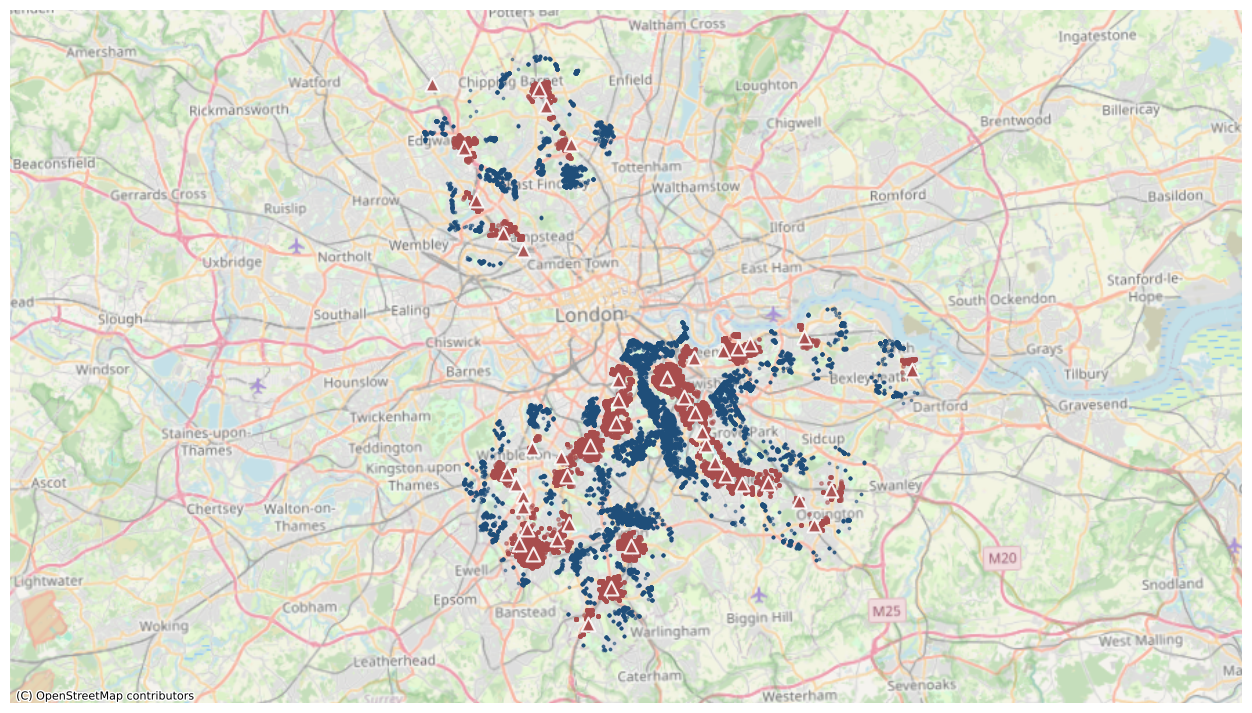

In [32]:
# Map: treated houses alongside ring control group
print(f'Total houses: {len(houses_treated)}')
print(f'Total stations: {len(stations_treated_df)}')

fig, ax = plt.subplots(figsize=(16, 9))
make_gdf(houses_control_ring).plot(ax=ax, color='#1f4e79', markersize=3, alpha=0.5, label='Ring Control')
make_gdf(houses_treated).plot(ax=ax, color='#a84d4d', markersize=6, alpha=0.5)
make_gdf(stations_treated_df).plot(ax=ax, color='#a84d4d', marker='^', markersize=100, alpha=0.9, edgecolor='white', linewidth=1.5)
finalize_map(ax)
plt.show()

#### Figure B1. Thameslink and South Western Railway areas used in the operator-control robustness check.

Total treated houses: 25108
Total treated stations: 45
Total SWR houses: 16906
Total SWR stations: 34


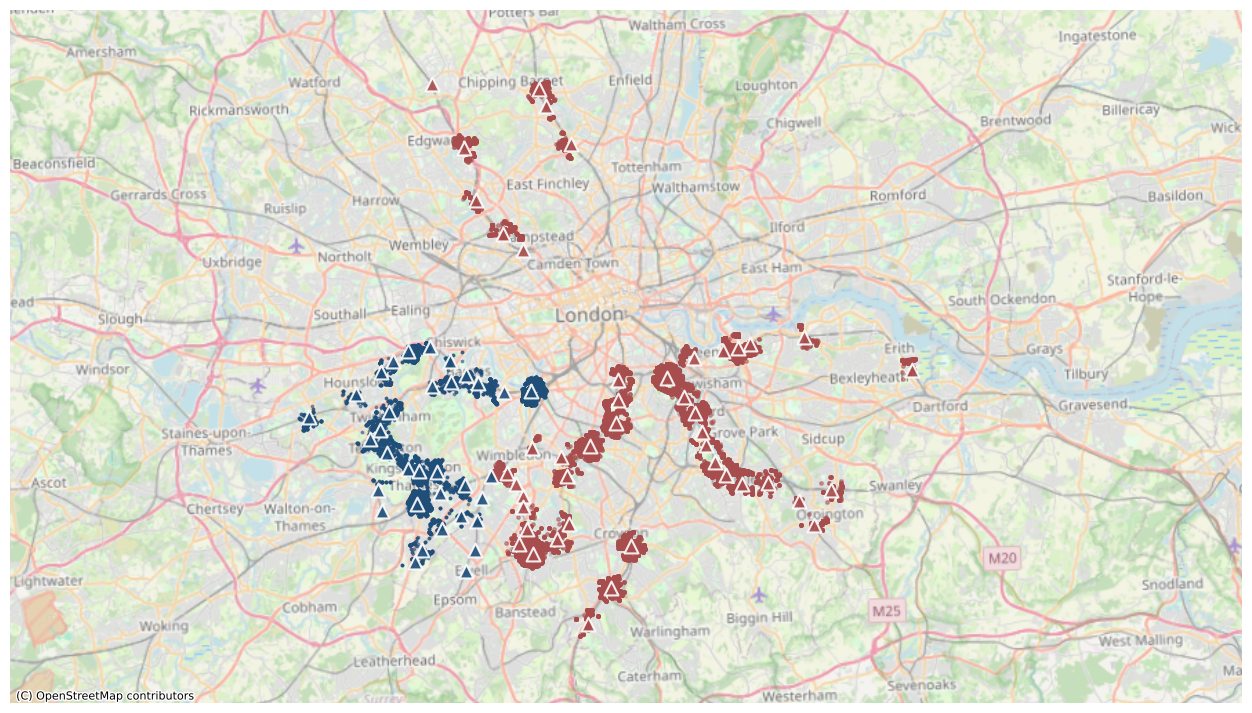

In [33]:
# Map: treated houses alongside SWR operator control
print(f'Total treated houses: {len(houses_treated)}')
print(f'Total treated stations: {len(stations_treated_df)}')
print(f'Total SWR houses: {len(houses_SWR)}')
print(f'Total SWR stations: {len(stations_SWR_df)}')

fig, ax = plt.subplots(figsize=(16, 9))
make_gdf(houses_SWR).plot(ax=ax, color='#1f4e79', markersize=3, alpha=0.5, label='SWR')
make_gdf(houses_treated).plot(ax=ax, color='#a84d4d', markersize=6, alpha=0.5)
make_gdf(stations_SWR_df).plot(ax=ax, color='#1f4e79', marker='^', markersize=100, alpha=0.9, edgecolor='white', linewidth=1.5)
make_gdf(stations_treated_df).plot(ax=ax, color='#a84d4d', marker='^', markersize=100, alpha=0.9, edgecolor='white', linewidth=1.5)
finalize_map(ax)
plt.show()

In [34]:
#### Figure B2. Thameslink and Southeastern areas used in the operator-control robustness check.

Total treated houses: 25108
Total treated stations: 45
Total Southeastern houses: 3156
Total Southeastern stations: 32


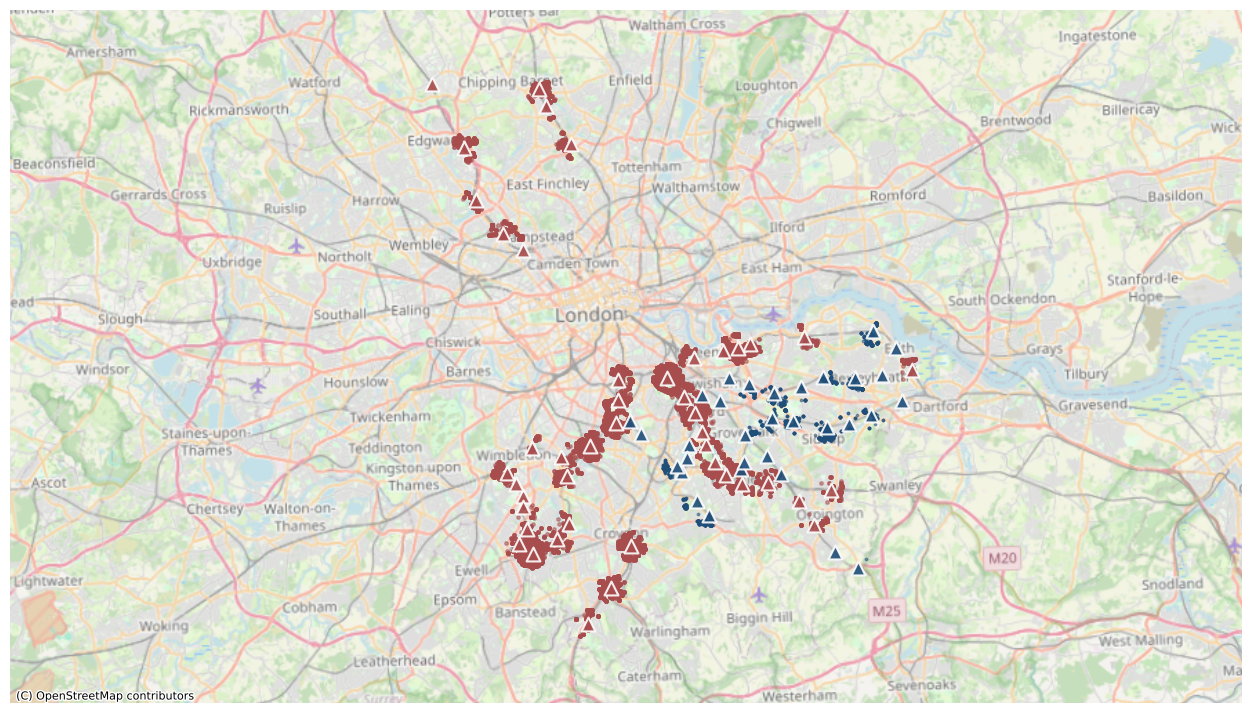

In [35]:
# Map: treated houses alongside Southeastern operator control
print(f'Total treated houses: {len(houses_treated)}')
print(f'Total treated stations: {len(stations_treated_df)}')
print(f'Total Southeastern houses: {len(houses_Southeastern)}')
print(f'Total Southeastern stations: {len(stations_Southeastern_df)}')

fig, ax = plt.subplots(figsize=(16, 9))
make_gdf(houses_Southeastern).plot(ax=ax, color='#1f4e79', markersize=3, alpha=0.5, label='Southeastern')
make_gdf(houses_treated).plot(ax=ax, color='#a84d4d', markersize=6, alpha=0.5)
make_gdf(stations_Southeastern_df).plot(ax=ax, color='#1f4e79', marker='^', markersize=100, alpha=0.9, edgecolor='white', linewidth=1.5)
make_gdf(stations_treated_df).plot(ax=ax, color='#a84d4d', marker='^', markersize=100, alpha=0.9, edgecolor='white', linewidth=1.5)
finalize_map(ax)
plt.show()


## Export Datasets for Stata

In [36]:
# ===== BASELINE EXPORTS: postcode-level pre/post filter =====
for name, df_src in datasets.items():
    df_filtered = apply_prepost_filter(df_src)
    n_filtered = save_dta(df_filtered, name)
    print(f"Saved {name}.dta ({n_filtered:,} houses)")


# ===== RELAXED-SPEC EXPORTS: unfiltered treatment/ring files for OA FE and station x ring FE =====
for name, df_src in station_ring_datasets.items():
    n_saved = save_dta(df_src, name)
    print(f"Saved {name}.dta ({n_saved:,} houses)")

# ===== MECHANISM EXPORT: transaction counts (no pre/post filter) =====
# Use ALL Greater London transactions, not filtered by pre/post requirement


# Get Greater London transactions with postcode coordinates
pp_mechanism = pp_all[pp_all['county'].isin(['GREATER LONDON'])].copy()

# Derive year/month from year_month string (e.g. "2020_11")
pp_mechanism['year'] = pp_mechanism['year_month'].str[:4].astype(int)
pp_mechanism['month'] = pp_mechanism['year_month'].str[5:7].astype(int)

pp_mechanism = pp_mechanism.merge(
    combined_df.iloc[:, [0, 2, 3]],
    left_on='postcode',
    right_on=combined_df.columns[0],
    how='inner'
)
pp_mechanism = pp_mechanism.rename(columns={
    combined_df.columns[2]: 'Eastings',
    combined_df.columns[3]: 'Northings'
})
pp_mechanism = pp_mechanism.drop(columns=[combined_df.columns[0]])
pp_mechanism = pp_mechanism.dropna(subset=['Eastings', 'Northings'])

# Convert to GeoDataFrame
pp_mechanism_gdf = gpd.GeoDataFrame(
    pp_mechanism,
    geometry=gpd.points_from_xy(pp_mechanism['Eastings'], pp_mechanism['Northings']),
    crs='EPSG:27700'
)

# Find transactions within 1km of treated stations (treatment)
near_treated = gpd.sjoin(
    pp_mechanism_gdf,
    stations_treated_gdf.set_geometry('buffer_1km'),
    how='inner',
    predicate='within'
)
treated_indices = near_treated.index.unique()

# Find transactions within 3km (for ring outer boundary)
near_3km = gpd.sjoin(
    pp_mechanism_gdf,
    stations_treated_gdf.set_geometry('buffer_3km'),
    how='inner',
    predicate='within'
)
within_3km_indices = set(near_3km.index.unique())

# Find transactions within 1.5km (for ring inner boundary)
near_1_5km = gpd.sjoin(
    pp_mechanism_gdf,
    stations_treated_gdf.set_geometry('buffer_1_5km'),
    how='inner',
    predicate='within'
)
within_1_5km_indices = set(near_1_5km.index.unique())

# Ring: 1.5-3km
ring_indices = within_3km_indices - within_1_5km_indices

# Remove transactions near Underground/DLR
near_tube = gpd.sjoin(pp_mechanism_gdf, tube_dlr_buffers, how='inner', predicate='within')
tube_indices = set(near_tube.index.unique())

treated_final = set(treated_indices) - tube_indices
ring_final = ring_indices - tube_indices

# Build mechanism dataset
pp_treated = pp_mechanism.loc[list(treated_final)].copy()
pp_treated['treated'] = 1
pp_ring = pp_mechanism.loc[list(ring_final)].copy()
pp_ring['treated'] = 0

pp_mech = pd.concat([pp_treated, pp_ring], ignore_index=True)

# Assign nearest treated station
mech_coords = pp_mech[['Eastings', 'Northings']].astype(float).values
diffs = mech_coords[:, np.newaxis, :] - _treated_coords[np.newaxis, :, :]
dists = np.sqrt((diffs ** 2).sum(axis=2))
pp_mech['nearest_station'] = _treated_names[dists.argmin(axis=1)]

# Count transactions per station × year_month × treated/control
tx_counts = pp_mech.groupby(['nearest_station', 'year_month', 'treated']).agg(
    n_transactions=('price', 'size')
).reset_index()

# Export to Stata
tx_counts.columns = tx_counts.columns.str.replace(' ', '_')
for col in tx_counts.columns:
    if tx_counts[col].dtype == 'object':
        tx_counts[col] = tx_counts[col].astype(str)
tx_counts.to_stata('output/mechanism_transactions.dta', write_index=False)
print(f"Saved mechanism_transactions.dta ({len(tx_counts):,} station-month-ring observations)")


Saved main_treated_1000.dta (21,624 houses)
Saved robustness_treated_500.dta (7,924 houses)
Saved robustness_treated_1500.dta (32,758 houses)
Saved main_control_1500_3000.dta (21,550 houses)
Saved robustness_control_swr.dta (14,578 houses)
Saved robustness_control_southeastern.dta (2,722 houses)
Saved robustness_treated_ringfe.dta (25,108 houses)
Saved robustness_control_ringfe.dta (25,749 houses)
Saved mechanism_transactions.dta (10,234 station-month-ring observations)
